### Config

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from hydra import compose, initialize
from pathlib import Path
from omegaconf import OmegaConf

initialize(config_path="../config", version_base="1.3")
cfg = compose(config_name="config")
print(OmegaConf.to_yaml(cfg))

sys.path.insert(0, str(cfg.paths.project_root))

from src.phyid_decomposition import MultiPromptPhyID, PromptPhyID, PhyIDTimeSeries
from src.ranked_deactivation_analysis import RankedDeactivationAnalysis


paths:
  project_root: /home/p84400019/projects/consciousness-llms/IT-LLMs/
  model_path: ${model.company}/${model.model_family}/${model.model_size}/${model.it}/
  activation_method: ${time_series.node_type}/${time_series.node_activation}/${time_series.projection_method}/
  phyid_method: ${paths.activation_method}phyid_tau-${phyid.tau}/phyid_kind-${phyid.kind}/phyid_redundancy-${phyid.redundancy}/
  data_dir: ${paths.project_root}data/${paths.model_path}${generation.name}/
  data_activations_dir: ${paths.data_dir}activations/
  data_activations_file: ${paths.data_activations_dir}multi_prompt_activations.pkl
  data_phyid_dir: ${paths.data_dir}phyid/${paths.phyid_method}
  data_phyid_file: ${paths.data_phyid_dir}multi_prompt_phyid.pkl
  data_phyid_file_data_array: ${paths.data_phyid_dir}multi_prompt_phyid.nc
  plot_dir: ${paths.project_root}plots/${paths.model_path}${generation.name}/
  plot_time_series_dir: ${paths.plot_dir}time_series/${paths.activation_method}
  plot_phyid_dir: ${path

/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Model and PhyID Decomposition

#### Load model and tokenizer

Load model with Flash Attention to Avoid Attention Caching

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model = AutoModelForCausalLM.from_pretrained(
    cfg.model.hf_name,
    torch_dtype=torch.float16,      # ★ key line ★
    device_map="auto",
    trust_remote_code=True,
)
model.config._attn_implementation = "flash_attention_2"

tokenizer = AutoTokenizer.from_pretrained(
    cfg.model.hf_name,
    use_fast=True,
    trust_remote_code=True,
)

#### Load the PhyID decomposition

In [ ]:
data_phyid_path = cfg.paths.data_phyid_dir

print(f"Loading phyid from {data_phyid_path}")
phyid = MultiPromptPhyID.load_average_prompt_phyid(dir_path=data_phyid_path)

Loading phyid from /home/p84400019/projects/consciousness-llms/IT-LLMs/data/alibaba/qwen-3/1.7B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/


In [ ]:
# phyid.compute_extra_atoms()
# file_path = data_phyid_path + "average.pkl"
# phyid.save(file_path)

PromptPhyID successfully saved to '/home/p84400019/projects/consciousness-llms/IT-LLMs/data/alibaba/qwen-3/1.7B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/average.pkl'.


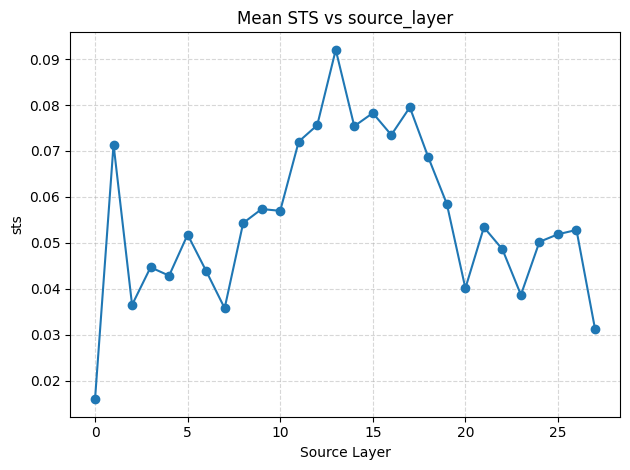

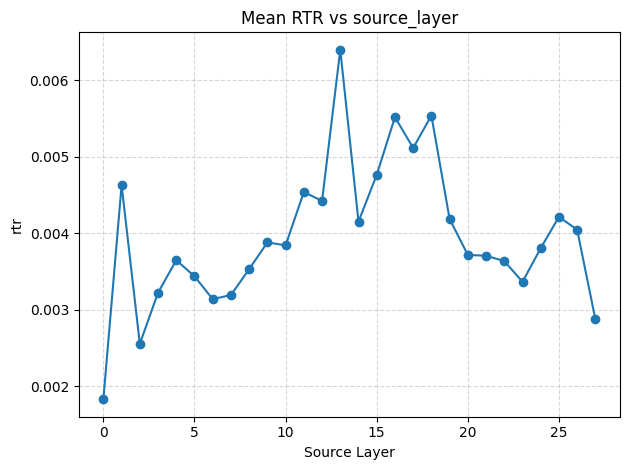

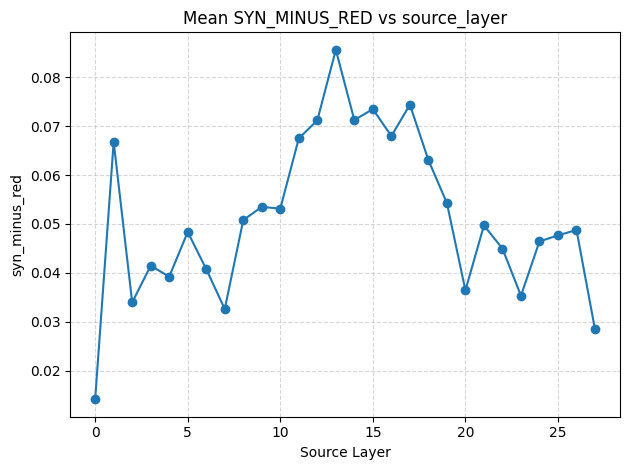

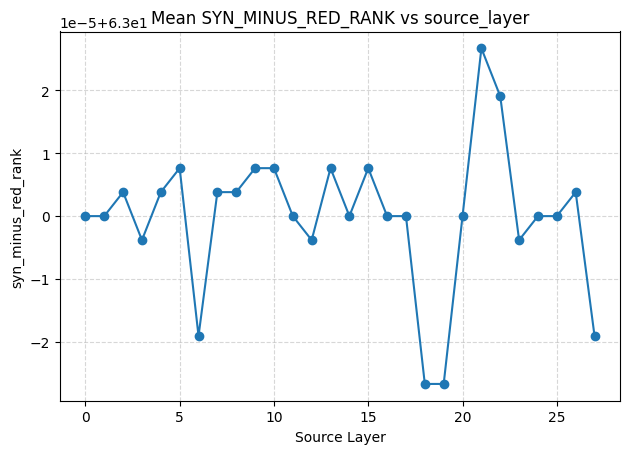

In [ ]:
phyid.plot_mean_along('sts', 'source_layer')
phyid.plot_mean_along('rtr', 'source_layer')
phyid.plot_mean_along('syn_minus_red', 'source_layer')
phyid.plot_mean_along('syn_minus_red_rank', 'source_layer')

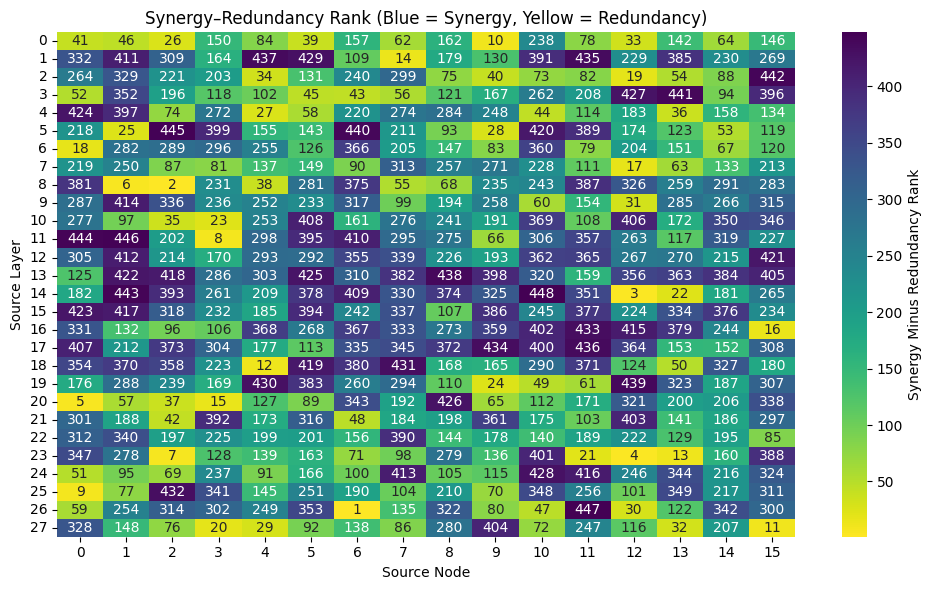

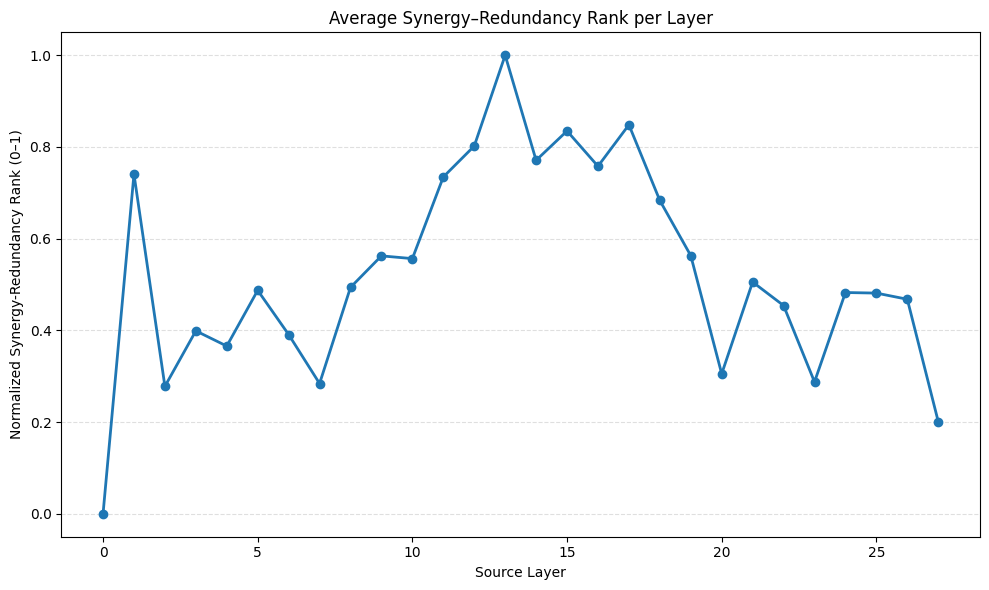

Synergy–Redundancy Rank of N03-L08: 231


In [ ]:
phyid.__dict__.pop("syn_minus_red_rank", None)
node_ranking = phyid.syn_minus_red_rank
phyid.plot_syn_minus_red_rank_per_node(node_ranking)
phyid.plot_syn_minus_red_rank_per_layer(node_ranking)
print(f"Synergy–Redundancy Rank of N03-L08: {node_ranking.sel(source_node=3, source_layer=8).values}")

### Ablations

In [ ]:
deactivation = RankedDeactivationAnalysis(
    model=model,
    tokenizer=tokenizer,
    prompts=OmegaConf.to_container(cfg.generation.prompts, resolve=True),
    chat_template=cfg.model.apply_chat_template,
    node_ranking=node_ranking,
    max_new_tokens=128
)

Shape of tokenized prompts: dict_keys(['all'])
Shape of tokenized prompts: KeysView({'input_ids': tensor([[40]]), 'attention_mask': tensor([[1]])})
Shape of tokenized prompts: torch.Size([1, 1])
Shape of tokenized prompts: torch.Size([1, 1])


In [ ]:
results = deactivation.run(
    deactivate_k_nodes_per_iteration=5,
    max_deactivated_nodes=None,
    micro_batch_size=1
)
print(results)

Processing micro-batch 1 of 108...


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Processing micro-batch 2 of 108...


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Processing micro-batch 3 of 108...


...

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Processing micro-batch 7 of 108...


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Processing micro-batch 8 of 108...


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
